Detecção de fraudes em cartões de crédito utilizando Machine Learning:
Esse projeto busca encontrar um bom modelo de machine learning para realizar a detecção de fraudes em transações feitas por cartões de crédito.


# observação | na pagina inicial é informado que as variáveis passaram por uma transformação conhecida como Análise de Componentes Principais.
Como podemos ver, as features são todas numéricas, e foram descaracterizadas (devido à privacidade e a segurança). Assim, os nomes das colunas são representados por [V1,V2,V3…,V28] 

Além disso, na página original dos dados, também é informado que as variáveis passaram por uma transformação conhecida como Análise de Componentes Principais (Principal Component Analysis - PCA).

# É importante dizer que isso não influência no aprendizado do algoritmo de classificação e que é bastante comum nos depararmos com dados anonimizados devido à privacidade ou segurança necessários.

# PCA
é uma técnica para redução da dimensionalidade feita através de cálculos matemáticos e cálculos de matrizes onde o algoritmo encontra um conjunto novo de recursos - os chamados componentes - através das variáveis já existentes. Esses componentes são em número menor às variáveis originais e cada componente extraído tenta explicar, por si só, uma grande porcentagem da variabilidade dos dados.

# variáveis que conhecemos são:

Time = Número de segundos decorridos entre esta transação e a primeira transação no dataset;
Amount = Valor da transação;
Class = Nossa variável alvo, ou seja, é a variável que desejamos que nosso algoritmo consiga prever. Classifica as transações como autênticas ou fraudulentas assumindo dois valores: 0 para transações autênticas e 1 para transações fraudulentas.

# dataset
https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [78]:
# import das bibliotecas 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")


In [79]:
# import do dados
df = pd.read_csv('https://www.dropbox.com/s/jcnd83bfbdjm45b/creditcard.csv?dl=1')


In [80]:
# exibição da estrtutura do dataframe e valores iniciais contigo nele
df.shape[0]
df.shape[1]

print('linhas: ', df.shape[0])
print('colunas: ', df.shape[1])

linhas:  284807
colunas:  31


In [81]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [82]:
# Visualizando informações estatísticas do dataset

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [83]:
# se consta valores nulos

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

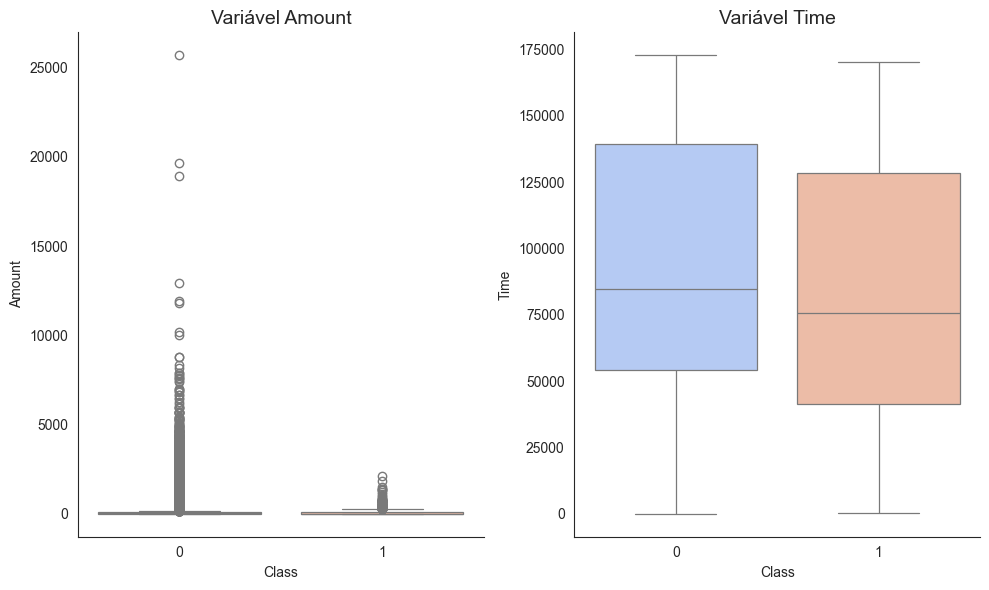

In [84]:
# Alterando o estilo do seaborn
sns.set_style("white")

# Criando a figura
fig, ax = plt.subplots(figsize=(10,6), ncols=2)
sns.despine(top=True, right=True)

# Plotando a variável Amount
sns.boxplot(x=df.Class, y=df.Amount, ax=ax[0], linewidth=.9, palette="coolwarm")
ax[0].set_title("Variável Amount", size='14')

# Plotando a variável Time
sns.boxplot(x=df.Class, y=df.Time,ax=ax[1], linewidth=.9, palette="coolwarm")
ax[1].set_title("Variável Time", size='14')

# Exibindo
plt.tight_layout()

In [6]:
# Informações estatísticas da variável Amount em relação a variável class==1

df = [(df.Class == 1)]['amount'].describe()

<>:3: SyntaxWarning: list indices must be integers or slices, not str; perhaps you missed a comma?
<>:3: SyntaxWarning: list indices must be integers or slices, not str; perhaps you missed a comma?
C:\Users\marco\AppData\Local\Temp\ipykernel_7164\3324974353.py:3: SyntaxWarning: list indices must be integers or slices, not str; perhaps you missed a comma?
  df = [(df.Class == 1)]['amount'].describe()


NameError: name 'df' is not defined

A presença de outliers fica ainda mais nítida ao exibimos as informações estatísticas da variável em relação à variável alvo em seus valores para transações fraudulentas (1) e para transações autênticas (0). Basta olharmos para o valor bastante grande no desvio padrão, além da grande diferença nas médias e medianas em comparação aos valores mínimos e máximos em ambos os casos.

# Próximas etapas o de tratamento desses outliers em busca de um maior desempenho em nosso modelo de classificação

Seguindo em nossa análise exploratória, iremos agora:

Plotar um gráfico countplot para ver o balanceamento do dataset
Plotar uma matriz de correlação

In [ ]:
# Exibindo as informações estatísiticas
print("---Contagem dos valores da variável Class.---\n")
print("0 = Transações autênticas  1 = Transações fraudulentas\n")
print(df.Class.value_counts())
print("\nTransações fraudulentas representam apenas {:.3%}".format(((df.Class ==1 ).sum()) / (df.shape[0])), "dos dados\n.")

# Plotando o gráfico do balanceamento do dataset
fig, ax = plt.subplots(figsize=(7,5))
sns.despine(top=True, right=True)
sns.countplot(x="Class", data=df,  palette="coolwarm", ax=ax)
ax.set_title("Balanceamento do dataset", size=14)
plt.tight_layout()

Como informamos no tópico, os dados do dataset estão bastante desbalanceados, e com o gráfico acima percebemos isso nitidamente. Essa discrepância nos dados atrapalhará o modelo e precisará ser tratada.

In [ ]:
# Plotando a matriz de correlação
fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(df.corr(), linewidth=.05, cmap="coolwarm", ax=ax)
ax.set_title("Matriz de correlação", size=14)

plt.tight_layout()

A matriz de correlação não nos dá quase informação nenhuma, isso pode ser devido ao alto desbalanceamento presente nos dados, como vimos anteriormente.
Com isso podemos passar para a etapa de tratamento e preparação dos dados para serem utilizados em nosso modelo de classificação.


# Tratamento e preparação dos Dados

Nessa etapa iremos tratar os problemas que encontramos na etapa de análise de modo a preparar os dados da melhor maneira para serem utilizados pelo algoritmo de machine learning e alcançarmos um bom desempenho na previsão das transações. Para isso, precisaremos:

- Normalizar os dados que ainda não haviam sido pré-processados (Time e Amount)
- Buscar e tratar os outliers
- Dividir o conjunto de dados entre treino e teste para serem utilizados no modelo
- Balancear o conjunto de dados
- Avaliar a qualidade dos dados após os tratamentos realizados

In [ ]:
# Importando os pacotes auxiliares de Machine Learning para tratamento dos dados
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
# Normalizando as variáveis Time e Amount

# Copiando o dataframe para um novo
df_norm = df.copy()

# Instanciando o StandardScaler
std_scaler = StandardScaler()

# Normalizando
df_norm["TimeNorm"] = std_scaler.fit_transform(df.Time.values.reshape(-1,1))
df_norm["AmountNorm"] = std_scaler.fit_transform(df.Amount.values.reshape(-1,1))

# Excluir as variáveis não normalizadas do DataFrame
df_norm.drop(["Time", "Amount"], axis=1, inplace=True)

# Exibindo o DataFrame com as variáveis normalizadas
df_norm.head()

Com o código acima realizamos a normalização das variáveis e armazenamos seus valores normalizados em duas novas variáveis TimeNorm e AmountNorm. 

Com esse processo não temos o risco de o algoritmo dar mais ou menos peso à essas colunas devido aos seus valores estarem em escala diferente do restante do dataset, já que essa técnica coloca os valores das colunas informadas em uma escala igual ao restante dos dados sem retirar as informações que possuem.

Passaremos agora para a análise e tratamento dos outliers. Trataremos apenas a variável Amount, que agora é AmountNorm, já que não identificamos outliers na variável Time. Para a limpeza utilizaremos a regra do IQR Score.

In [ ]:
# Calculando o Q1 e o Q3
q1 = df_norm.AmountNorm.quantile(.25)
q3 = df_norm.AmountNorm.quantile(.75)

# Calculando o IQR
IQR = q3 - q1

# Definindo os limites superior e inferior
sup = q3 + 1.5 * IQR
inf = q1 - 1.5 * IQR

# Limpando os outliers
df_clean = df_norm.copy()
df_clean.drop(df_clean[df_clean.AmountNorm > sup].index, axis=0, inplace=True)
df_clean.drop(df_clean[df_clean.AmountNorm < inf].index, axis=0, inplace=True)

In [ ]:
# Criando a figura
fig, ax = plt.subplots(figsize=(10,6), ncols=2)
sns.despine(top=True, right=True)

# Plotando a variável Amount antes da limpeza dos outliers
sns.boxplot(x=df_norm.Class, y=df_norm.AmountNorm, ax=ax[0], linewidth=.9, palette="coolwarm")
ax[0].set_title("Variável Amount antes da limpeza dos outliers", size='14')

# Plotando a variável Amount depois da limpeza dos outliers
sns.boxplot(x=df_clean.Class, y=df_clean.AmountNorm, ax=ax[1], linewidth=.9, palette="coolwarm")
ax[1].set_title("Variável Amount depois da limpeza dos outliers", size='14')

# Exibindo
plt.tight_layout()

In [ ]:
# Exibindo as informações estatísiticas antes da limpeza

print("Exibindo as informações estatísiticas antes da limpeza")
print(df_norm.AmountNorm.describe())

# Exibindo as informações estatísiticas após a limpeza
print("\nExibindo as informações estatísiticas após a limpeza")
print(df_clean.AmountNorm.describe())

É visível a melhoria da qualidade dos dados após a técnica do IQR Score ter sido aplicada para realizar a limpeza dos outliers. 
Através do boxplot conseguimos visualizar agora os quartis e os limites superior e inferior, algo que sequer era visível antes da limpeza. 

# Agora vamos dividir os dados entre treino e teste
Essa etapa é essencial na construção de modelos de machine learning, pois nos permite treinar o modelo com parte dos dados e testar seu desempenho com restante, simulando como seria seu comportamento se o aplicássemos em dados completamente novos. Um dos passos a serem feitos durante essa divisão é a separação dos dados entre feature matrix e target vector, que são:

Feature matrix: matriz com todas as variáveis que serão utilizadas pelo modelo para prever a variável alvo
Target vector: vetor alvo (ou variável alvo), é a variável que desejamos que seja prevista corretamente pelo modelo

In [ ]:
# Dividindo os dados entre treino e teste

# Separando os dados entre feature matrix e target vector
X = df_clean.drop("Class", axis=1)
y = df_clean.Class

# Separar os dados entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, stratify=y)

# Agora iremos realizar o balanceamento dos dados

Aplicaremos a técnica de undersampling: De maneira resumida, essa técnica consiste em diminuir a quantidade de observações com a maior número de classificação de modo a equalizar.

In [ ]:
# Balanceando os dados 

# Instanciando o RandomUnderSampler
rus = RandomUnderSampler()

#Balanceando X_train e y_train
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

In [ ]:
# Exibindo as informações estatísiticas após o balanceamento
print("---Contagem dos valores da variável Class após o balanceamento.---\n")
print("0 = Transações autênticas  1 = Transações fraudulentas\n")
print(y_train_rus.value_counts())


# Plotando o gráfico do balanceamento do dataset após o balanceamento
fig, ax = plt.subplots(figsize=(7,5))
sns.despine(top=True, right=True)
sns.countplot(x=y_train_rus, palette="coolwarm", ax=ax)
ax.set_title("Balanceamento do dataset", size=14)
plt.tight_layout()

Como nosso dataset continha poucas observações para a classificação Class == 1
a técnica de undersampling reduziu a quantidade de observações para a classificação majoritária Class == 0 equalizando ambas e, assim, balanceando os dados.

Agora que nossos dados estão tratados, normalizadas, limpos de outliers e balanceados, podemos passar para a etapa de construção do modelo de machine learning para, enfim, atacarmos o problema principal: construir um modelo que possa detectar transações fraudulentas em cartões de crédito.

# Construção do modelo de Machine Learning 

conforme explicado na etapa do dicionário de variáveis: 0 - para transações autênticas e 1 - para transações fraudulentas. Isso significa dizer que essa variável assume valores discretos, pode ser apenas 1 ou 0.


# Para esse tipo de problemas usamos modelos de Classificação, que classificará a variável dentro dos valores discretos que ela pode assumir 

Existem diversos modelos que podem ser aplicados em tarefas de classificação, nesse estudo aplicaremos dois: Regressão Logística e Árvore de decisão.
Em seguida avaliaremos qual dos dois teve o melhor desempenho na resolução do problema.

In [86]:
# Base
import numpy as np
import pandas as pd

# Split e modelos
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Balanceamento
from imblearn.under_sampling import RandomUnderSampler

# Métricas
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

# Visualização
import matplotlib.pyplot as plt

In [87]:
# Exemplo esperado:
X = df.drop('Class', axis=1)
y = df['Class']

print(X.shape, y.shape)

(284807, 30) (284807,)


Por que usar:
Separar variáveis independentes (X) da variável alvo (y)

**O que resolve:**

organiza o problema como supervisionado

permite treinar modelos corretamente

In [88]:
# Split Treino/Teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y  # importante para manter proporção de fraude
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (199364, 30)
Teste: (85443, 30)


# Split Treino/Teste: Separar dados para treino e validação

**O que resolve:**

evita overfitting

simula dados reais (modelo nunca viu o teste)

stratify mantém proporção de fraude

# Normalização
Padronizar escala das variáveis

**O que resolve:**

melhora desempenho da regressão logística

evita que variáveis grandes dominem o modelo

In [89]:
# Balanceamento (RUS)

rus = RandomUnderSampler(random_state=2)

X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("Antes do balanceamento:")
print(pd.Series(y_train).value_counts())

print("\nDepois do balanceamento (RUS):")
print(pd.Series(y_train_rus).value_counts())

Antes do balanceamento:
Class
0    199020
1       344
Name: count, dtype: int64

Depois do balanceamento (RUS):
Class
0    344
1    344
Name: count, dtype: int64


# Balanceamento (RUS)
Fraude é extremamente rara (dataset desbalanceado)

**Oque resolve:**

reduz viés para classe majoritária

melhora detecção de fraude (Recall)

In [90]:
# Treinamento dos Modelos

np.random.seed(2)

# Regressão Logística
logistic_model = LogisticRegression(C=0.01, max_iter=1000)
logistic_model.fit(X_train_rus, y_train_rus)

logistic_y_pred = logistic_model.predict(X_test)
logistic_y_proba = logistic_model.predict_proba(X_test)[:, 1]

# Árvore de Decisão
tree_model = DecisionTreeClassifier(criterion="entropy", max_depth=6, random_state=2)
tree_model.fit(X_train_rus, y_train_rus)

tree_y_pred = tree_model.predict(X_test)
tree_y_proba = tree_model.predict_proba(X_test)[:, 1]

# Treinamento dos Modelos
Comparar dois modelos diferentes

**Oque resolve:**

Logística- baseline interpretável  

Árvore - captura não linearidade

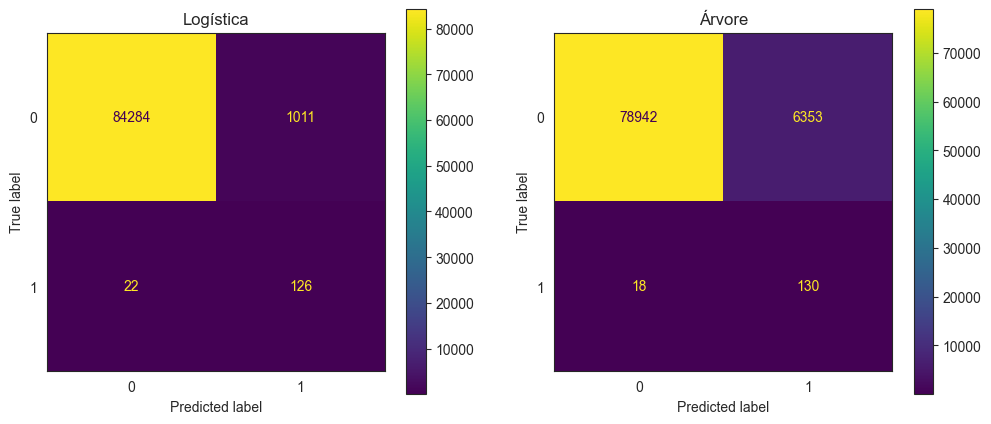

In [91]:
# Matriz de Confusão 

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, logistic_y_pred)
ConfusionMatrixDisplay(cm_log).plot(ax=ax[0])
ax[0].set_title("Logística")

cm_tree = confusion_matrix(y_test, tree_y_pred)
ConfusionMatrixDisplay(cm_tree).plot(ax=ax[1])
ax[1].set_title("Árvore")

plt.show()

# Matriz de Confusão
Visualizar erros do modelo

**Oque resolve:**

identifica falsos negativos (fraude não detectada)

identifica falsos positivos (bloqueio indevido)

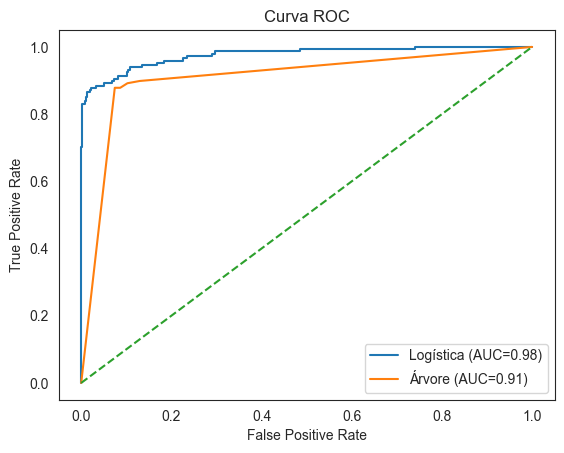

In [93]:
# Curva ROC (Comparação)

fpr_log, tpr_log, _ = roc_curve(y_test, logistic_y_proba)
auc_log = auc(fpr_log, tpr_log)

fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_y_proba)
auc_tree = auc(fpr_tree, tpr_tree)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f'Logística (AUC={auc_log:.2f})')
plt.plot(fpr_tree, tpr_tree, label=f'Árvore (AUC={auc_tree:.2f})')
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

#  Curva ROC
Avaliar performance geral do modelo

**O que resolve:**

mede separação entre fraude vs normal

AUC alto = modelo melhor

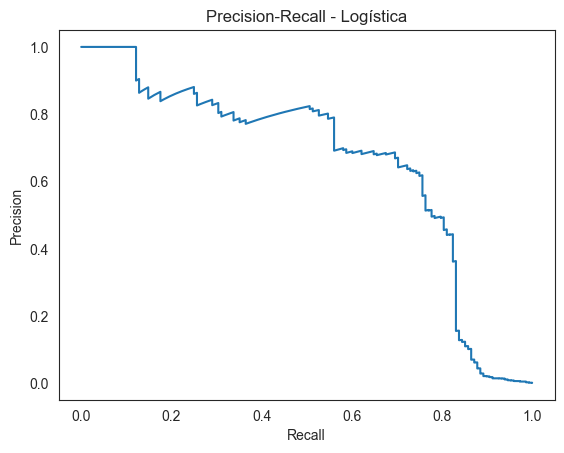

In [94]:
# Precision-Recall (importante para fraude)

precision, recall, _ = precision_recall_curve(y_test, logistic_y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall - Logística")
plt.show()

# Precision-Recall Curve
Mais adequada para dados desbalanceados

**O que resolve:**

ROC pode mascarar erro em fraude

mostra desempenho real na classe minoritária

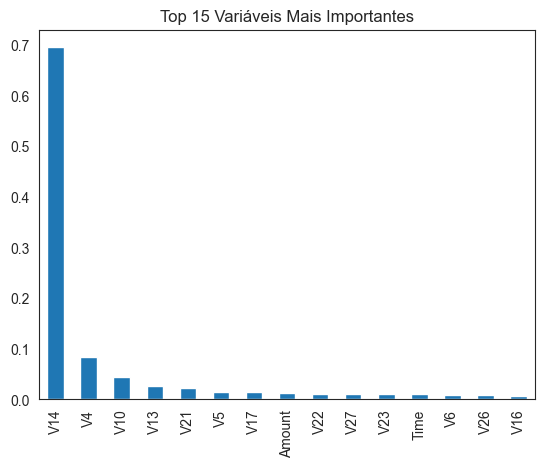

In [95]:
# Importância das Variáveis (Árvore)

feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=X_train.columns
)

feature_importance.sort_values(ascending=False).head(15).plot(kind='bar')
plt.title("Top 15 Variáveis Mais Importantes")
plt.show()

# Importância das Variáveis
Entender o que influencia o modelo

**O que resolve:**

traz explicabilidade

gera insights de negócio

ajuda auditoria

| Etapa              | Problema que resolve        |
| ------------------ | --------------------------- |
| Split              | evita overfitting           |
| Normalização       | melhora modelo              |
| Balanceamento      | resolve fraude rara         |
| Modelos            | comparação de abordagem     |
| Confusão           | entender erros              |
| Relatório          | métricas detalhadas         |
| ROC                | performance geral           |
| PR Curve           | avaliação correta em fraude |
| Feature importance | explicabilidade             |


In [99]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predições
y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:,1]

# Métricas
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nAUC:")
print(roc_auc_score(y_test, y_proba))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     85295
           1       0.11      0.85      0.20       148

    accuracy                           0.99     85443
   macro avg       0.56      0.92      0.60     85443
weighted avg       1.00      0.99      0.99     85443


Matriz de Confusão:
[[84284  1011]
 [   22   126]]

AUC:
0.9755250062184817


# desepenho do modelo e proximo passo ajustar o modelo

O modelo apresentou AUC de 0.97, indicando excelente capacidade de separação.
No entanto, observei um trade-off importante: o recall foi alto (85%), garantindo boa detecção de fraudes,
mas a precision foi baixa (11%), indicando muitos falsos positivos.

Para resolver isso, vou aplicar técnicas como ajuste de threshold e comparação entre RUS e SMOTE, buscando equilibrar a detecção de fraude com a experiência do cliente.

In [102]:
# GridSearchCV (melhor modelo)

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_rus, y_train_rus)

best_model = grid.best_estimator_

print(grid.best_params_)

{'C': 0.01, 'class_weight': None}


**O que resolve:**

- encontra melhor configuração automaticamente
- class_weight='balanced' ajuda em fraude
- melhora AUC sem mexer em dados

In [103]:
# Comparar RUS vs SMOTE (dados melhores)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=2)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Treinar modelo com SMOTE
model_smote = LogisticRegression(**grid.best_params_, max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [104]:
# Comparação objetiva

from sklearn.metrics import roc_auc_score

# RUS
y_proba_rus = best_model.predict_proba(X_test)[:,1]
auc_rus = roc_auc_score(y_test, y_proba_rus)

# SMOTE
y_proba_smote = model_smote.predict_proba(X_test)[:,1]
auc_smote = roc_auc_score(y_test, y_proba_smote)

print("AUC RUS:", auc_rus)
print("AUC SMOTE:", auc_smote)

AUC RUS: 0.9755250062184817
AUC SMOTE: 0.9649377042791076


**O que resolve:**

- escolhe melhor abordagem de balanceamento
- SMOTE geralmente melhora precision

In [106]:
# Threshold tuning (decisão de negócio)
# Encontrar melhor threshold

import numpy as np
from sklearn.metrics import precision_score, recall_score

y_proba = y_proba_smote  # ou RUS (escolha o melhor)

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    
    results.append((t, precision, recall))

for r in results:
    print(f"Threshold: {r[0]:.2f} | Precision: {r[1]:.2f} | Recall: {r[2]:.2f}")

Threshold: 0.10 | Precision: 0.02 | Recall: 0.91
Threshold: 0.15 | Precision: 0.03 | Recall: 0.89
Threshold: 0.20 | Precision: 0.05 | Recall: 0.88
Threshold: 0.25 | Precision: 0.06 | Recall: 0.87
Threshold: 0.30 | Precision: 0.07 | Recall: 0.86
Threshold: 0.35 | Precision: 0.09 | Recall: 0.86
Threshold: 0.40 | Precision: 0.10 | Recall: 0.86
Threshold: 0.45 | Precision: 0.12 | Recall: 0.86
Threshold: 0.50 | Precision: 0.13 | Recall: 0.85
Threshold: 0.55 | Precision: 0.15 | Recall: 0.85
Threshold: 0.60 | Precision: 0.17 | Recall: 0.85
Threshold: 0.65 | Precision: 0.18 | Recall: 0.85
Threshold: 0.70 | Precision: 0.20 | Recall: 0.85
Threshold: 0.75 | Precision: 0.22 | Recall: 0.85
Threshold: 0.80 | Precision: 0.25 | Recall: 0.84
Threshold: 0.85 | Precision: 0.29 | Recall: 0.84


# Melhor escolha de threshold
Recomendação: 0.80 – 0.85

**Motivo:**
- Recall praticamente não muda (0.85 -> 0.84)
- Precision mais que dobra (0.13 -> 0.25 – 0.29)

**Resultado:** ganho enorme com perda mínima

# Impacto real

**Antes (0.5):**

- Precision: 13%
- Recall:    85%

**Depois (0.85):**

- Precision: 29%
- Recall:    84%

# Tradução de negócio

**Antes:**

 - muitos alertas falsos
- cliente irritado
- custo alto

**Depois:**

- menos ruído
- mesma capacidade de detectar fraude
- operação mais eficiente

In [107]:
# Modelo FINAL

# Configuração ideal:

threshold = 0.85

y_proba = best_model.predict_proba(X_test)[:,1]
y_pred_final = (y_proba >= threshold).astype(int)

In [1]:
import joblib

model_package = {
    "model": logistic_model,   # seu modelo treinado
    "scaler": scaler,          # scaler já fitado
    "threshold": 0.85          # seu threshold escolhido
}

joblib.dump(model_package, 'models/fraud_model.pkl')

NameError: name 'logistic_model' is not defined